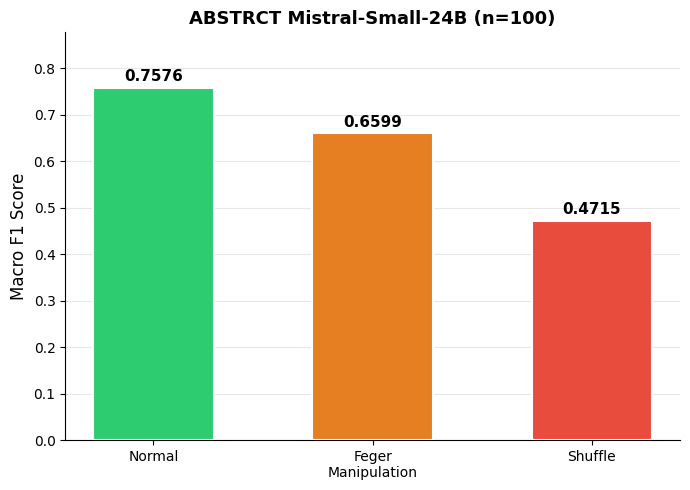

In [3]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

with open("baseline_100_mistralai_Mistral-Small-24B-Instruct-2501.json") as f:
    data = json.load(f)

overall = data["overall"]
f1_normal = overall["mean_macro_f1_original"]
f1_feger = overall["mean_macro_f1_feger"]
f1_shuffle = overall["mean_macro_f1_shuffle"]
delta_feger = overall["mean_delta_feger"]
delta_shuffle = overall["mean_delta_shuffle"]

labels = ["Normal", "Feger\nManipulation", "Shuffle"]
scores = [f1_normal, f1_feger, f1_shuffle]
colors = ["#2ecc71", "#e67e22", "#e74c3c"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, scores, color=colors, width=0.55, edgecolor="white", linewidth=1.5, zorder=3)

# Value labels on bars
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f"{score:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=11)


ax.set_ylabel("Macro F1 Score", fontsize=12)
ax.set_title("ABSTRCT Mistral-Small-24B (n=100)", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(scores) + 0.12)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("sanity_check_barplot.png", dpi=150, bbox_inches="tight")
plt.show()